# Alouette-2 - General Quality Analysis
---

This script performs a general quality analysis of the Alouette-2 metadata extraction process. It evaluates how records were processed by categorizing outcomes into successful metadata extraction, extraction failures, and exclusion conditions. For records where metadata extraction was successful, the script also analyzes and visualizes prediction confidence scores.

In addition, the analysis validates extracted satellite numbers, identifies missing or unexpected satellite values, and reports the number of station identifiers that were successfully mapped to known station locations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

The 04_Imageupload_20260428_Metadata_Extraction.csv for Alouette-2 metadata extraction was produced using the 04_Extract_Metadata.py script.  

In [49]:
df = pd.read_csv(
    Path(
        r"L:\DATA\ISIS\Imageupload_20260428_Processing\04_Imageupload_20260428_Metadata_Extraction.csv"
        ),
    encoding="cp1252"
    )

## Metadata Extraction Summary

Raw metadata processing outcomes

In [72]:
# Combine failure reasons, exclusion reasons, and successful predictions
processing_outcomes = (
    df['failure_reason']
    .fillna(df['exclusion_reason'])
    .fillna('Model Predicted Metadata')
)

processing_outcome_counts = processing_outcomes.value_counts()

print("\nProcessing Outcome Summary")
print("-" * 50)

for outcome, count in processing_outcome_counts.items():
    print(f"{outcome}: {count:,}")

print("-" * 50)
print(f"Total Rows: {len(df):,}")


Processing Outcome Summary
--------------------------------------------------
Model Predicted Metadata: 17,233
intentionally excluded for processing due to image incompatibility with the current pipeline: 573
ocr_contains_letters: 278
detection_failure - No usable foreground sequence, FAST boxes, or foreground fallback boxes: 278
invalid_detected_length_14: 217
invalid_detected_length_16: 73
invalid_detected_length_13: 49
invalid_sanitized_length_0: 30
invalid_detected_length_12: 26
invalid_sanitized_length_14: 23
invalid_sanitized_length_1: 19
invalid_detected_length_17: 17
invalid_detected_length_11: 15
invalid_detected_length_10: 11
invalid_sanitized_length_16: 10
invalid_detected_length_6: 9
invalid_sanitized_length_13: 9
invalid_detected_length_28: 8
invalid_detected_length_8: 8
invalid_sanitized_length_2: 8
invalid_sanitized_length_3: 7
invalid_detected_length_9: 6
invalid_sanitized_length_4: 6
invalid_detected_length_0: 6
invalid_detected_length_30: 6
invalid_detected_length_7:

Summarized Metadata Processing Outcomes

In [68]:
processing_outcomes_map = {
    'Excluded: intentionally excluded for processing due to image incompatibility with the current pipeline': 'Intentionally Excluded',
    'invalid_detected_length': 'Invalid Length (Detected)',
    'invalid_sanitized_length': 'Invalid Length (Sanitized)',
    'invalid_detected_characters': 'Invalid Characters',
    'detection_failure - No usable foreground sequence, FAST boxes, or foreground fallback boxes':'Text Detection Failure',
    'ocr_contains_letters':'Prediction Contained Letters'  
}


Metadata Processing Outcome Summary
------------------------------------------------------------
Metadata Predicted by Model              17,233
Intentionally Excluded                   573
Invalid Length (Detected)                505
Prediction Contained Letters             278
Text Detection Failure                   278
Invalid Length (Sanitized)               142
------------------------------------------------------------
Total Cases                              19,009


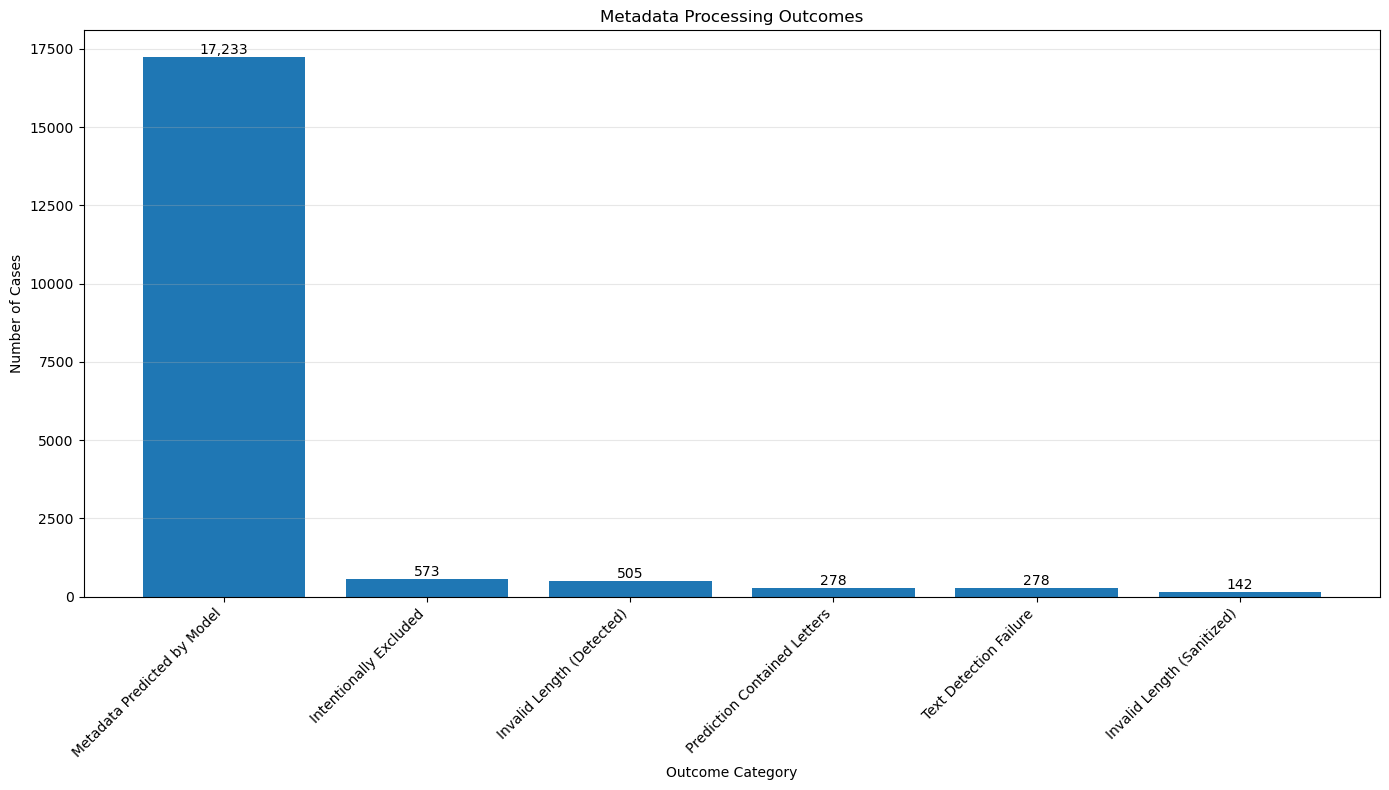

In [92]:
# Create a unified outcome category
outcome_category = pd.Series(index=df.index, dtype='object')

# Successful extraction
outcome_category[df['metadata_extracted'] == True] = 'Metadata Predicted by Model'

# Failure reasons
failure_mask = (
    (df['metadata_extracted'] != True)
    & df['failure_reason'].notna()
)

outcome_category[failure_mask] = (
    df.loc[failure_mask, 'failure_reason']
      .astype(str)
      .str.replace(r'_\d+$', '', regex=True)
)

# Exclusion reasons
exclusion_mask = (
    (df['metadata_extracted'] != True)
    & df['failure_reason'].isna()
    & df['exclusion_reason'].notna()
)

outcome_category[exclusion_mask] = (
    'Excluded: '
    + df.loc[exclusion_mask, 'exclusion_reason'].astype(str)
)

# Anything uncategorized
outcome_category = outcome_category.fillna('Other / Unknown')

# Rename categories for readability
outcome_category = outcome_category.replace(processing_outcomes_map)

# Count outcomes
outcome_counts = outcome_category.value_counts()


# Print Summary
print("\nMetadata Processing Outcome Summary")
print("-" * 60)

for outcome, count in outcome_counts.items():
    print(f"{outcome:<40} {count:,}")

print("-" * 60)
print(f"{'Total Cases':<40} {len(df):,}")

# Plot Summary
save_figure_path = ''
plt.figure(figsize=(14, 8))

bars = plt.bar(
    outcome_counts.index,
    outcome_counts.values
)

plt.title('Metadata Processing Outcomes')
plt.xlabel('Outcome Category')
plt.ylabel('Number of Cases')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

if save_figure_path:
    plt.savefig(save_figure_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## Predicted Metadata Confidence

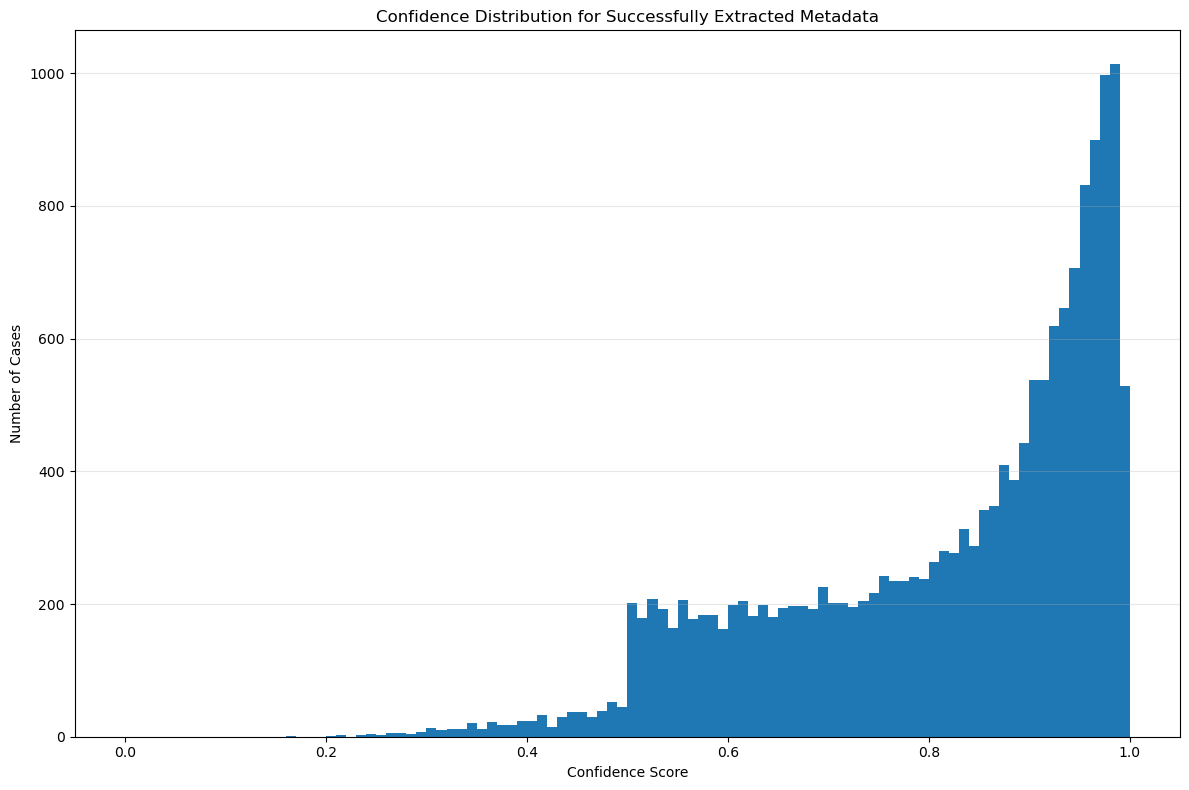

In [91]:
save_figure_path = ''
success_confidence = df.loc[
    df['metadata_extracted'] == True,
    'prediction_confidence'
].dropna()

plt.figure(figsize=(12, 8))

plt.hist(
    success_confidence,
    bins=np.arange(0, 1.01, 0.01)  # 1% bins
)

plt.title('Confidence Distribution for Successfully Extracted Metadata')
plt.xlabel('Confidence Score')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.3)

if save_figure_path:
    plt.savefig(save_figure_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## Validate Satellite Numbers

The satellite number is expected to be 20 for Alouette-2

In [78]:
expected_satellite_number = 20

count_expected_satellite_number = (df['satellite_number'] == expected_satellite_number).sum()

count_empty = (
    df['satellite_number'].isna().sum()
)

count_other = (
    (df['satellite_number'] != expected_satellite_number) &
    (df['satellite_number'].notna())
).sum()

print("\nSatellite Number Distribution")
print("-" * 35)
print(f"Satellite Number 20         : {count_expected_satellite_number:,}")
print(f"Other Satellite Numbers     : {count_other:,}")
print(f"Empty Satellite Number      : {count_empty:,}")
print(f"Total Cases                 : {len(df):,}")


Satellite Number Distribution
-----------------------------------
Satellite Number 20         : 17,128
Other Satellite Numbers     : 105
Empty Satellite Number      : 1,776
Total Cases                 : 19,009


Plotting the satellite numbers that are not the expected satellite number

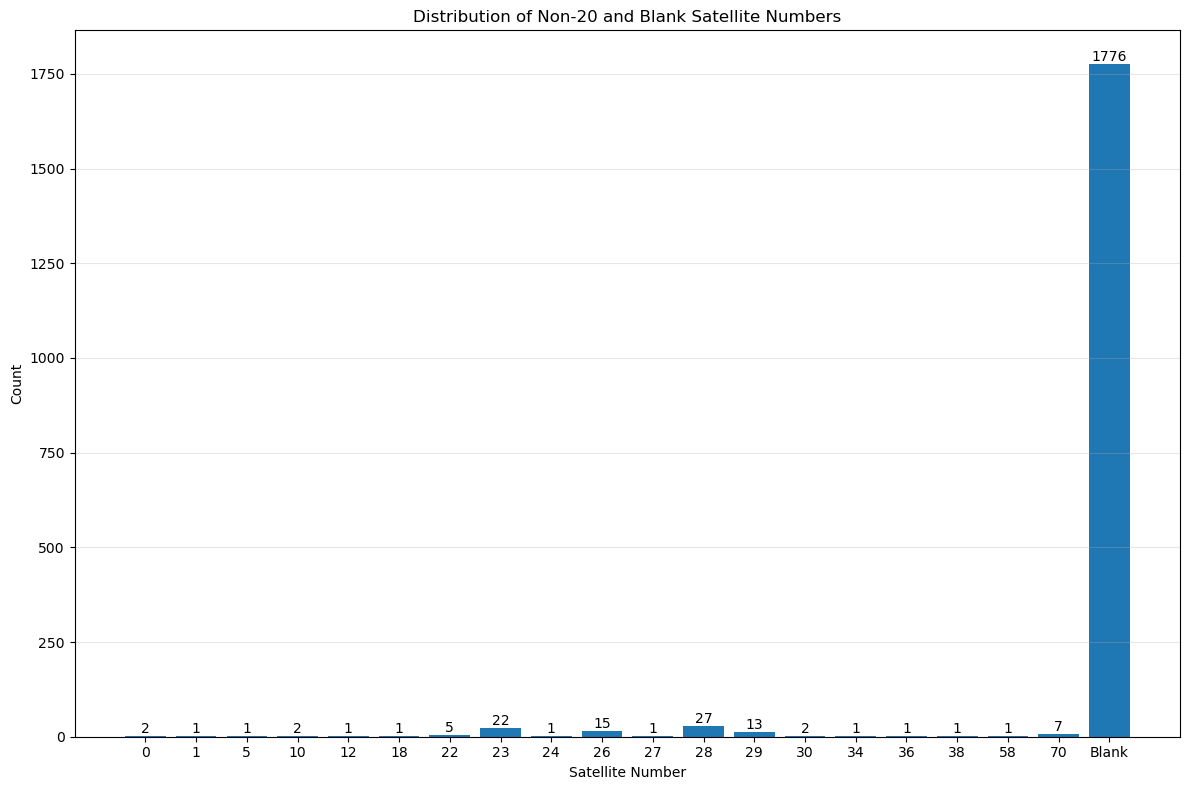

In [ ]:
# Create a copy of the satellite number column
satellite_status = df['satellite_number'].copy()

# Replace blank strings with labels
satellite_status = satellite_status.fillna('Blank')

# Convert numeric values to integer strings (e.g., 21.0 -> '21')
satellite_status = satellite_status.apply(
    lambda x: str(int(x)) if isinstance(x, (int, float)) and pd.notna(x) else str(x)
)

# Count all values except the expected satellite number
incorrect_satellite_number = (
    satellite_status[satellite_status != str(expected_satellite_number)]
    .value_counts()
)

# Sort numerically and put Blank at the end
numeric_labels = sorted(
    [x for x in incorrect_satellite_number.index if x not in ['Blank']],
    key=int
)

ordered_labels = numeric_labels

if 'Blank' in incorrect_satellite_number.index:
    ordered_labels.append('Blank')

incorrect_satellite_number = incorrect_satellite_number.reindex(ordered_labels)

# Create plot
save_figure_path = ''

plt.figure(figsize=(12, 8))

bars = plt.bar(
    incorrect_satellite_number.index,
    incorrect_satellite_number.values
)

plt.xlabel('Satellite Number')
plt.ylabel('Count')
plt.title('Distribution of Non-20 and Blank Satellite Numbers')
plt.grid(True, axis='y', alpha=0.3)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

if save_figure_path:
    plt.savefig(save_figure_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [80]:
# Create a new column where non-empty satellite numbers are set to 20
# missing/blank values remain unchanged
df['Adjusted_Satellite_Number'] = df['satellite_number'].where(
    df['satellite_number'].isna(),
    20
)

Save CSV with adjusted satellite numbers

In [54]:
df.to_csv(
    Path(r'L:\DATA\ISIS\Imageupload_20260428_Processing\05_Imageupload_20260428_metadata_satellite_number_adjusted.csv'), 
    index=False)

## Station Number Extraction Summary



Station Information Extraction Summary
--------------------------------------------------
Absent station information due to failed metadata extraction : 1,776
Metadata extracted, Station_ID blank                         : 57
Metadata extracted, Station_ID present                       : 17,176
Total Cases                                                  : 19,009


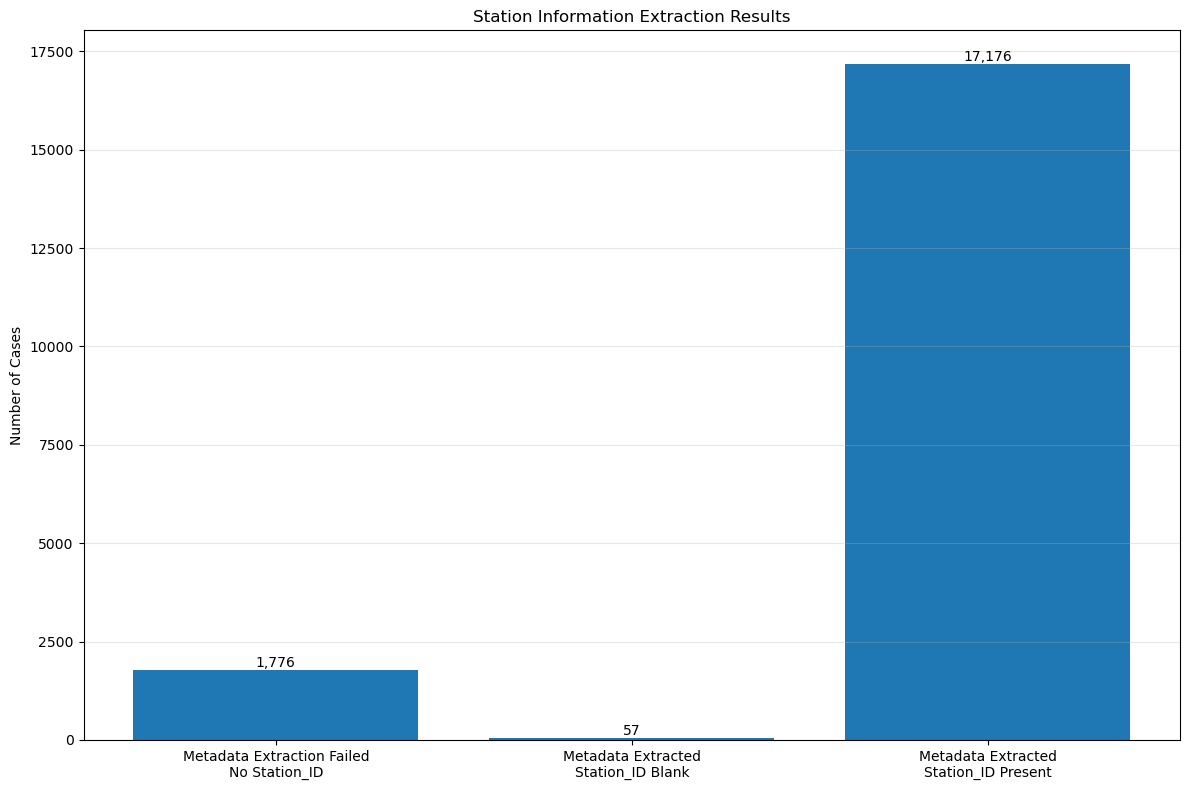

In [ ]:
loss_df = df[df['processed_image_class'] == 'loss']

# Total loss records
count_loss = len(loss_df)

# metadata_extracted = True and Station_ID is blank/missing
count_station_blank = len(
    df[
        (df['metadata_extracted'] == True) &
        (
            df['Station_ID'].isna() |
            (df['Station_ID'] == '')
        )
    ]
)

# metadata_extracted = True and Station_ID is populated
count_station_present = len(
    df[
        (df['metadata_extracted'] == True) &
        df['Station_ID'].notna() &
        (df['Station_ID'] != '')
    ]
)

print("\nStation Information Extraction Summary")
print("-" * 50)
print(f"Absent station information due to failed metadata extraction : {count_loss:,}")
print(f"Metadata extracted, Station_ID blank                         : {count_station_blank:,}")
print(f"Metadata extracted, Station_ID present                       : {count_station_present:,}")
print(f"Total Cases                                                  : {len(df):,}")



# Plot data
categories = [
    'Metadata Extraction Failed\nNo Station_ID',
    'Metadata Extracted\nStation_ID Blank',
    'Metadata Extracted\nStation_ID Present'
]

counts = [
    count_loss,
    count_station_blank,
    count_station_present
]

# Create plot
save_figure_path = ''

plt.figure(figsize=(12, 8))
bars = plt.bar(categories, counts)

plt.title('Station Information Extraction Results')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.3)

# Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom'
    )

if save_figure_path:
    plt.savefig(save_figure_path, dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()